# Friction Indicator Engineering & Participation Segmentation 

### Load Processed Data from Notebook 1

In [1]:


"""

Notebook 2: Feature Engineering & Customer Segmentation

Goal: Create 30+ predictive features and identify customer segments

"""

# Install missing packages in the notebook environment
%pip install -q matplotlib scikit-learn seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print("NOTEBOOK 2: FEATURE ENGINEERING")
print("="*70)

# Load processed data from Notebook 1
analysis_sample = pd.read_csv('../data/processed/analysis_sample_base.csv')
delivered_orders = pd.read_csv('../data/processed/delivered_orders.csv')

print(f"\n Data loaded successfully!")
print(f"Analysis sample: {analysis_sample.shape}")
print(f"Delivered orders: {delivered_orders.shape}")






Note: you may need to restart the kernel to use updated packages.
NOTEBOOK 2: FEATURE ENGINEERING

 Data loaded successfully!
Analysis sample: (28020, 10)
Delivered orders: (96478, 9)


# Load Additional Datasets For Feature Engineering 

In [2]:
# ============================================================================
# LOAD ADDITIONAL DATASETS FOR FEATURE ENGINEERING
# ============================================================================

print("\n" + "="*70)
print("LOADING ADDITIONAL DATA")
print("="*70)

# Load datasets we'll need for features
order_items = pd.read_csv('../data/raw/olist_order_items_dataset.csv')
payments = pd.read_csv('../data/raw/olist_order_payments_dataset.csv')
reviews = pd.read_csv('../data/raw/olist_order_reviews_dataset.csv')
products = pd.read_csv('../data/raw/olist_products_dataset.csv')

print(f"\n Additional data loaded:")
print(f"   Order items: {order_items.shape}")
print(f"   Payments: {payments.shape}")
print(f"   Reviews: {reviews.shape}")
print(f"   Products: {products.shape}")



LOADING ADDITIONAL DATA

 Additional data loaded:
   Order items: (112650, 7)
   Payments: (103886, 5)
   Reviews: (99224, 7)
   Products: (32951, 9)


# Delivery Features 

In [3]:
# ============================================================================
# FEATURE SET 1: DELIVERY FEATURES
# ============================================================================

print("\n" + "="*70)
print("FEATURE ENGINEERING - DELIVERY METRICS")
print("="*70)

# Merge delivery data
feature_df = analysis_sample.copy()

# Prepare delivery metrics in delivered_orders (compute if missing)
# Use only orders present in our analysis sample to speed up processing
delivery_subset = delivered_orders[delivered_orders['order_id'].isin(feature_df['order_id'])].copy()

# Ensure datetime columns are proper datetimes
delivery_subset['order_delivered_customer_date'] = pd.to_datetime(
    delivery_subset['order_delivered_customer_date'], errors='coerce'
)
delivery_subset['order_estimated_delivery_date'] = pd.to_datetime(
    delivery_subset['order_estimated_delivery_date'], errors='coerce'
)

# Compute delivery_delay in days (delivered - estimated)
delivery_subset['delivery_delay'] = (
    delivery_subset['order_delivered_customer_date'] - delivery_subset['order_estimated_delivery_date']
).dt.days

# Create a simple categorical delay label
def _delay_category(days):
    if pd.isna(days):
        return np.nan
    if days < 0:
        return 'early'
    if days == 0:
        return 'on_time'
    if 0 < days <= 5:
        return 'late'
    return 'very_late'

delivery_subset['delay_category'] = delivery_subset['delivery_delay'].apply(_delay_category)

# Select the features we need and merge
delivery_features = delivery_subset[['order_id', 'delivery_delay', 'delay_category']].copy()
feature_df = feature_df.merge(delivery_features, on='order_id', how='left')

# Create binary delivery features (NaN comparisons yield False -> 0)
feature_df['is_late_delivery'] = (feature_df['delivery_delay'] > 0).astype(int)
feature_df['is_very_late'] = (feature_df['delivery_delay'] > 5).astype(int)
feature_df['is_early_delivery'] = (feature_df['delivery_delay'] < -5).astype(int)

print(f"\n Created 5 delivery features:")
print(f"   1. delivery_delay (continuous)")
print(f"   2. delay_category (categorical)")  
print(f"   3. is_late_delivery (binary)")
print(f"   4. is_very_late (binary)")
print(f"   5. is_early_delivery (binary)")

print(f"\nDelivery Feature Summary:")
print(f"   Late deliveries: {feature_df['is_late_delivery'].sum():,} ({feature_df['is_late_delivery'].mean():.1%})")
print(f"   Very late (>5 days): {feature_df['is_very_late'].sum():,} ({feature_df['is_very_late'].mean():.1%})")



FEATURE ENGINEERING - DELIVERY METRICS

 Created 5 delivery features:
   1. delivery_delay (continuous)
   2. delay_category (categorical)
   3. is_late_delivery (binary)
   4. is_very_late (binary)
   5. is_early_delivery (binary)

Delivery Feature Summary:
   Late deliveries: 1,021 (3.6%)
   Very late (>5 days): 589 (2.1%)


# Economic Friction Indicators 

In [4]:
print("\n" + "="*70)
print("FEATURE SET 2: ECONOMIC FRICTION INDICATORS")
print("="*70)

# Get payment data for first orders
payment_data = payments[payments['order_id'].isin(feature_df['order_id'])].copy()

# Aggregate payments per order
payment_agg = payment_data.groupby('order_id').agg({
    'payment_value': 'sum',
    'payment_installments': 'max',
    'payment_type': lambda x: x.mode()[0] if len(x) > 0 else 'unknown'
}).reset_index()

# Get order item data
item_data = order_items[order_items['order_id'].isin(feature_df['order_id'])].copy()

item_agg = item_data.groupby('order_id').agg({
    'price': 'sum',
    'freight_value': 'sum',
    'order_item_id': 'count'
}).reset_index()
item_agg.columns = ['order_id', 'total_price', 'total_freight', 'num_items']

# Merge economic data
economic_data = payment_agg.merge(item_agg, on='order_id', how='left')

# Feature 6: Payment value
economic_data['payment_value'] = economic_data['payment_value']

# Feature 7: Freight percentage of order
economic_data['freight_pct'] = (
    economic_data['total_freight'] / economic_data['payment_value'] * 100
).fillna(0)

# Feature 8: Is high freight (>20%)
economic_data['is_high_freight'] = (economic_data['freight_pct'] > 20).astype(int)

# Feature 9: Number of items
economic_data['num_items'] = economic_data['num_items']

# Feature 10: Price per item
economic_data['price_per_item'] = (
    economic_data['total_price'] / economic_data['num_items']
).fillna(0)

# Feature 11: Uses installments
economic_data['uses_installments'] = (economic_data['payment_installments'] > 1).astype(int)

# Merge
feature_df = feature_df.merge(
    economic_data[['order_id', 'payment_value', 'freight_pct', 'is_high_freight',
                   'num_items', 'price_per_item', 'uses_installments', 'payment_type']], 
    on='order_id', 
    how='left'
)

print(f"\n Created 7 economic friction indicators:")
print(f"   6. payment_value (continuous, R$)")
print(f"   7. freight_pct (continuous, %)")
print(f"   8. is_high_freight (binary, >20%)")
print(f"   9. num_items (count)")
print(f"   10. price_per_item (continuous, R$)")
print(f"   11. uses_installments (binary)")
print(f"   12. payment_type (categorical)")

print(f"\n Economic Statistics:")
print(f"   Average order value: R$ {feature_df['payment_value'].mean():.2f}")
print(f"   Average freight %: {feature_df['freight_pct'].mean():.1f}%")
print(f"   High freight orders: {feature_df['is_high_freight'].sum():,} ({feature_df['is_high_freight'].mean():.1%})")



FEATURE SET 2: ECONOMIC FRICTION INDICATORS

 Created 7 economic friction indicators:
   6. payment_value (continuous, R$)
   7. freight_pct (continuous, %)
   8. is_high_freight (binary, >20%)
   9. num_items (count)
   10. price_per_item (continuous, R$)
   11. uses_installments (binary)
   12. payment_type (categorical)

 Economic Statistics:
   Average order value: R$ 161.18
   Average freight %: 20.9%
   High freight orders: 12,398.0 (44.2%)


# Geographic Friction Indicators 

In [5]:
print("\n" + "="*70)
print("FEATURE SET 3: GEOGRAPHIC FRICTION INDICATORS")
print("="*70)

# Ensure customers dataset is loaded (avoid NameError if not present)
if 'customers' not in globals():
	try:
		customers = pd.read_csv('../data/raw/olist_customers_dataset.csv')
		print(f"Loaded customers dataset: {customers.shape}")
	except Exception as e:
		raise RuntimeError(
			"Could not load customers dataset. Make sure '../data/raw/olist_customers_dataset.csv' exists."
		) from e

# Get customer state from original customers data
customer_geo = customers[['customer_unique_id', 'customer_state', 'customer_city']].copy()

# Merge geography
feature_df = feature_df.merge(customer_geo, on='customer_unique_id', how='left')

# Feature 13: Is remote state (not SP/RJ/MG)
major_states = ['SP', 'RJ', 'MG']
feature_df['is_remote_state'] = (~feature_df['customer_state'].isin(major_states)).astype(int)

# Feature 14: Is Southeast region
southeast_states = ['SP', 'RJ', 'MG', 'ES']
feature_df['is_southeast'] = (feature_df['customer_state'].isin(southeast_states)).astype(int)

# Feature 15: State (one-hot encode later)
# Keep as categorical for now

print(f"\n Created 3 geographic friction indicators:")
print(f"   13. is_remote_state (binary)")
print(f"   14. is_southeast (binary)")
print(f"   15. customer_state (categorical, will encode)")

print(f"\n Geographic Distribution:")
print(f"   Remote states: {feature_df['is_remote_state'].sum():,} ({feature_df['is_remote_state'].mean():.1%})")
print(f"   Southeast region: {feature_df['is_southeast'].sum():,} ({feature_df['is_southeast'].mean():.1%})")
print(f"\nTop 5 states:")
print(feature_df['customer_state'].value_counts().head())



FEATURE SET 3: GEOGRAPHIC FRICTION INDICATORS
Loaded customers dataset: (99441, 5)

 Created 3 geographic friction indicators:
   13. is_remote_state (binary)
   14. is_southeast (binary)
   15. customer_state (categorical, will encode)

 Geographic Distribution:
   Remote states: 10,530 (35.5%)
   Southeast region: 19,764 (66.7%)

Top 5 states:
customer_state
SP    11498
RJ     4085
MG     3531
RS     1871
PR     1520
Name: count, dtype: int64


# Product/Category Indicators 

In [6]:
print("\n" + "="*70)
print("FEATURE SET 4: PRODUCT FRICTION INDICATORS")
print("="*70)

# Get product data (select only needed cols and rename to avoid collisions)
product_data = item_data[['order_id', 'product_id']].merge(
    products[['product_id', 'product_category_name', 'product_weight_g']],
    on='product_id',
    how='left'
)

# Keep first product per order (main item)
product_data = product_data.drop_duplicates('order_id')

# Rename merge columns to avoid _x/_y confusion
prod_merge = product_data[['order_id', 'product_category_name', 'product_weight_g']].rename(
    columns={
        'product_category_name': 'product_category_from_items',
        'product_weight_g': 'product_weight_g_from_items'
    }
)

# Merge product info (safe merge)
feature_df = feature_df.merge(prod_merge, on='order_id', how='left')

# Create a unified product_category_name column:
# Prefer category from items, else fall back to any existing category columns if present
feature_df['product_category_name'] = feature_df.get('product_category_from_items')

for candidate in ['product_category_name', 'product_category_name_x', 'product_category_name_y']:
    if candidate in feature_df.columns:
        feature_df['product_category_name'] = feature_df['product_category_name'].fillna(feature_df[candidate])

feature_df['product_category_name'] = feature_df['product_category_name'].fillna('unknown')

# Feature 17: Is repeatable category (from your earlier analysis!)
# Categories with >5% retention rate
repeatable_categories = [
    'cama_mesa_banho', 'beleza_saude', 'esporte_lazer',
    'informatica_acessorios', 'moveis_decoracao'
]
feature_df['is_repeatable_category'] = (
    feature_df['product_category_name'].isin(repeatable_categories)
).astype(int)

# Create unified product_weight_g (prefer merged weight, else any existing)
feature_df['product_weight_g'] = np.nan
for candidate in ['product_weight_g_from_items', 'product_weight_g', 'product_weight_g_x', 'product_weight_g_y']:
    if candidate in feature_df.columns:
        feature_df['product_weight_g'] = feature_df['product_weight_g'].fillna(feature_df[candidate])

# Feature 18: Product weight (kg)
feature_df['product_weight_kg'] = (feature_df['product_weight_g'] / 1000).fillna(0)

# Feature 19: Is heavy product (>5kg)
feature_df['is_heavy_product'] = (feature_df['product_weight_kg'] > 5).astype(int)

# (Optional) drop helper columns to keep dataframe tidy
for drop_col in ['product_category_from_items', 'product_weight_g_from_items',
                 'product_category_name_x', 'product_category_name_y',
                 'product_weight_g_x', 'product_weight_g_y']:
    if drop_col in feature_df.columns:
        feature_df.drop(columns=drop_col, inplace=True)

print(f"\n Created 4 product friction indicators:")
print(f"   16. product_category_name (categorical)")
print(f"   17. is_repeatable_category (binary)")
print(f"   18. product_weight_kg (continuous)")
print(f"   19. is_heavy_product (binary, >5kg)")

print(f"\n Product Statistics:")
print(f"   Repeatable categories: {feature_df['is_repeatable_category'].sum():,} ({feature_df['is_repeatable_category'].mean():.1%})")
print(f"   Average weight: {feature_df['product_weight_kg'].mean():.2f} kg")
print(f"   Heavy products: {feature_df['is_heavy_product'].sum():,} ({feature_df['is_heavy_product'].mean():.1%})")



FEATURE SET 4: PRODUCT FRICTION INDICATORS

 Created 4 product friction indicators:
   16. product_category_name (categorical)
   17. is_repeatable_category (binary)
   18. product_weight_kg (continuous)
   19. is_heavy_product (binary, >5kg)

 Product Statistics:
   Repeatable categories: 11,814 (39.9%)
   Average weight: 2.26 kg
   Heavy products: 3,793 (12.8%)


# Experience/Review Indicators 

In [7]:
print("\n" + "="*70)
print("FEATURE SET 5: EXPERIENCE FRICTION INDICATORS")
print("="*70)

# Get review data
review_data = reviews[reviews['order_id'].isin(feature_df['order_id'])][
    ['order_id', 'review_score', 'review_comment_message']
].copy()

# Feature 20: Review score
review_data['review_score'] = review_data['review_score']

# Feature 21: Is poor review (<3)
review_data['is_poor_review'] = (review_data['review_score'] < 3).astype(int)

# Feature 22: Has comment
review_data['has_comment'] = review_data['review_comment_message'].notna().astype(int)

# Merge reviews
feature_df = feature_df.merge(
    review_data[['order_id', 'review_score', 'is_poor_review', 'has_comment']], 
    on='order_id', 
    how='left'
)

# Fill missing reviews (assume no review = neutral)
feature_df['review_score'] = feature_df['review_score'].fillna(3)
feature_df['is_poor_review'] = feature_df['is_poor_review'].fillna(0)
feature_df['has_comment'] = feature_df['has_comment'].fillna(0)

print(f"\n Created 3 experience friction indicators:")
print(f"   20. review_score (1-5)")
print(f"   21. is_poor_review (binary, <3)")
print(f"   22. has_comment (binary)")

print(f"\n Experience Statistics:")
print(f"   Average review score: {feature_df['review_score'].mean():.2f}/5")
print(f"   Poor reviews: {feature_df['is_poor_review'].sum():,} ({feature_df['is_poor_review'].mean():.1%})")
print(f"   Orders with comments: {feature_df['has_comment'].sum():,} ({feature_df['has_comment'].mean():.1%})")



FEATURE SET 5: EXPERIENCE FRICTION INDICATORS

 Created 3 experience friction indicators:
   20. review_score (1-5)
   21. is_poor_review (binary, <3)
   22. has_comment (binary)

 Experience Statistics:
   Average review score: 4.22/5
   Poor reviews: 3,169.0 (10.6%)
   Orders with comments: 12,345.0 (41.3%)


# Temporal Indicators 

In [8]:
print("\n" + "="*70)
print("FEATURE SET 6: TEMPORAL FRICTION INDICATORS")
print("="*70)

# Get purchase timestamp
temporal_data = delivered_orders[delivered_orders['order_id'].isin(feature_df['order_id'])][
    ['order_id', 'order_purchase_timestamp']
].copy()

temporal_data['order_purchase_timestamp'] = pd.to_datetime(temporal_data['order_purchase_timestamp'])

# Feature 23: Purchase month
temporal_data['purchase_month'] = temporal_data['order_purchase_timestamp'].dt.month

# Feature 24: Purchase day of week (0=Monday, 6=Sunday)
temporal_data['purchase_day_of_week'] = temporal_data['order_purchase_timestamp'].dt.dayofweek

# Feature 25: Is weekend purchase
temporal_data['is_weekend'] = (temporal_data['purchase_day_of_week'] >= 5).astype(int)

# Feature 26: Is holiday season (Nov-Dec)
temporal_data['is_holiday_season'] = (temporal_data['purchase_month'].isin([11, 12])).astype(int)

# Merge temporal
feature_df = feature_df.merge(
    temporal_data[['order_id', 'purchase_month', 'purchase_day_of_week', 
                   'is_weekend', 'is_holiday_season']], 
    on='order_id', 
    how='left'
)

print(f"\n Created 4 temporal friction indicators:")
print(f"   23. purchase_month (1-12)")
print(f"   24. purchase_day_of_week (0-6)")
print(f"   25. is_weekend (binary)")
print(f"   26. is_holiday_season (binary)")

print(f"\n Temporal Statistics:")
print(f"   Weekend purchases: {feature_df['is_weekend'].sum():,} ({feature_df['is_weekend'].mean():.1%})")
print(f"   Holiday season: {feature_df['is_holiday_season'].sum():,} ({feature_df['is_holiday_season'].mean():.1%})")



FEATURE SET 6: TEMPORAL FRICTION INDICATORS

 Created 4 temporal friction indicators:
   23. purchase_month (1-12)
   24. purchase_day_of_week (0-6)
   25. is_weekend (binary)
   26. is_holiday_season (binary)

 Temporal Statistics:
   Weekend purchases: 6,912 (23.1%)
   Holiday season: 2 (0.0%)


# Feature Summary 

In [9]:
print("\n" + "="*70)
print("FEATURE ENGINEERING SUMMARY")
print("="*70)

# Count features created
numeric_features = feature_df.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = feature_df.select_dtypes(include=['object']).columns.tolist()

# Remove ID and target columns
numeric_features = [f for f in numeric_features if f not in 
                   ['dropped_off', 'customer_unique_id', 'total_orders']]

print(f"\n Feature Count:")
print(f"   Numeric features: {len(numeric_features)}")
print(f"   Categorical features: {len(categorical_features)}")
print(f"   Total: {len(numeric_features) + len(categorical_features)}")

print(f"\n Feature Categories:")
print(f"   Delivery Friction: 5 features")
print(f"   Economic Friction: 7 features")
print(f"   Geographic Friction: 3 features")
print(f"   Product Friction: 4 features")
print(f"   Experience Friction: 3 features")
print(f"   Temporal Friction: 4 features")

print(f"\n Feature List:")
for i, feat in enumerate(numeric_features, 1):
    print(f"   {i}. {feat}")




FEATURE ENGINEERING SUMMARY

 Feature Count:
   Numeric features: 24
   Categorical features: 11
   Total: 35

 Feature Categories:
   Delivery Friction: 5 features
   Economic Friction: 7 features
   Geographic Friction: 3 features
   Product Friction: 4 features
   Experience Friction: 3 features
   Temporal Friction: 4 features

 Feature List:
   1. days_since_first_order
   2. delivery_delay
   3. is_late_delivery
   4. is_very_late
   5. is_early_delivery
   6. payment_value
   7. freight_pct
   8. is_high_freight
   9. num_items
   10. price_per_item
   11. uses_installments
   12. is_remote_state
   13. is_southeast
   14. is_repeatable_category
   15. product_weight_g
   16. product_weight_kg
   17. is_heavy_product
   18. review_score
   19. is_poor_review
   20. has_comment
   21. purchase_month
   22. purchase_day_of_week
   23. is_weekend
   24. is_holiday_season


# Handle Missing Values

In [10]:
print("\n" + "="*70)
print("MISSING VALUE HANDLING")
print("="*70)

# Check missing values
missing = feature_df.isnull().sum()
missing_pct = (missing / len(feature_df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing': missing,
    'Percent': missing_pct
})
missing_df = missing_df[missing_df['Missing'] > 0].sort_values('Missing', ascending=False)

if len(missing_df) > 0:
    print("\n Features with missing values:")
    display(missing_df)
    
    # Fill numeric with median
    numeric_cols = feature_df[numeric_features].select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        if feature_df[col].isnull().sum() > 0:
            feature_df[col] = feature_df[col].fillna(feature_df[col].median())
            print(f"   Filled {col} with median")
    
    # Fill categorical with mode
    cat_cols = categorical_features
    for col in cat_cols:
        if feature_df[col].isnull().sum() > 0:
            feature_df[col] = feature_df[col].fillna(feature_df[col].mode()[0])
            print(f"   Filled {col} with mode")
else:
    print("\n No missing values found!")

print(f"\n Missing value handling complete")




MISSING VALUE HANDLING

 Features with missing values:


,Missing,Percent
product_weight_g,15,0.05
order_delivered_customer_date,1,0.00
delivery_delay,1,0.00
delay_category,1,0.00
payment_value,1,0.00
freight_pct,1,0.00
is_high_freight,1,0.00
num_items,1,0.00
price_per_item,1,0.00
uses_installments,1,0.00


   Filled delivery_delay with median
   Filled payment_value with median
   Filled freight_pct with median
   Filled is_high_freight with median
   Filled num_items with median
   Filled price_per_item with median
   Filled uses_installments with median
   Filled product_weight_g with median
   Filled order_delivered_customer_date with mode
   Filled delay_category with mode
   Filled payment_type with mode

 Missing value handling complete


# Light Customer Segmentation (KMeans)

In [12]:
# ============================================================================
# LIGHT CUSTOMER SEGMENTATION - KMEANS CLUSTERING
# ============================================================================

print("\n" + "="*70)
print("CUSTOMER SEGMENTATION - IDENTIFYING DISTINCT GROUPS")
print("="*70)

# NOTE: sklearn imports are already declared earlier in the notebook.
# Make sure 'days_to_delivery' exists in feature_df; compute it if missing.
if 'days_to_delivery' not in feature_df.columns:
    # compute days between purchase and delivery from delivered_orders
    tmp = delivered_orders[['order_id', 'order_purchase_timestamp', 'order_delivered_customer_date']].copy()
    tmp['order_purchase_timestamp'] = pd.to_datetime(tmp['order_purchase_timestamp'], errors='coerce')
    tmp['order_delivered_customer_date'] = pd.to_datetime(tmp['order_delivered_customer_date'], errors='coerce')
    tmp['days_to_delivery'] = (tmp['order_delivered_customer_date'] - tmp['order_purchase_timestamp']).dt.days

    # merge only the new column into feature_df (left join preserves feature_df order)
    feature_df = feature_df.merge(
        tmp[['order_id', 'days_to_delivery']],
        on='order_id',
        how='left'
    )

# Select features for clustering (behavioral signals)
features_to_use = [
    'payment_value',
    'freight_pct',
    'delivery_delay',
    'review_score',
    'num_items',
    'days_to_delivery'
]

# Keep only features that actually exist to avoid KeyError
existing_features = [f for f in features_to_use if f in feature_df.columns]
cluster_features = feature_df[existing_features].copy()

# Handle any remaining missing values
cluster_features = cluster_features.fillna(cluster_features.median())

print(f"\n Clustering on {len(cluster_features.columns)} behavioral features:")
for col in cluster_features.columns:
    print(f"   • {col}")


CUSTOMER SEGMENTATION - IDENTIFYING DISTINCT GROUPS

 Clustering on 6 behavioral features:
   • payment_value
   • freight_pct
   • delivery_delay
   • review_score
   • num_items
   • days_to_delivery



STEP 2: FINDING OPTIMAL NUMBER OF CLUSTERS
Computed features_scaled using StandardScaler


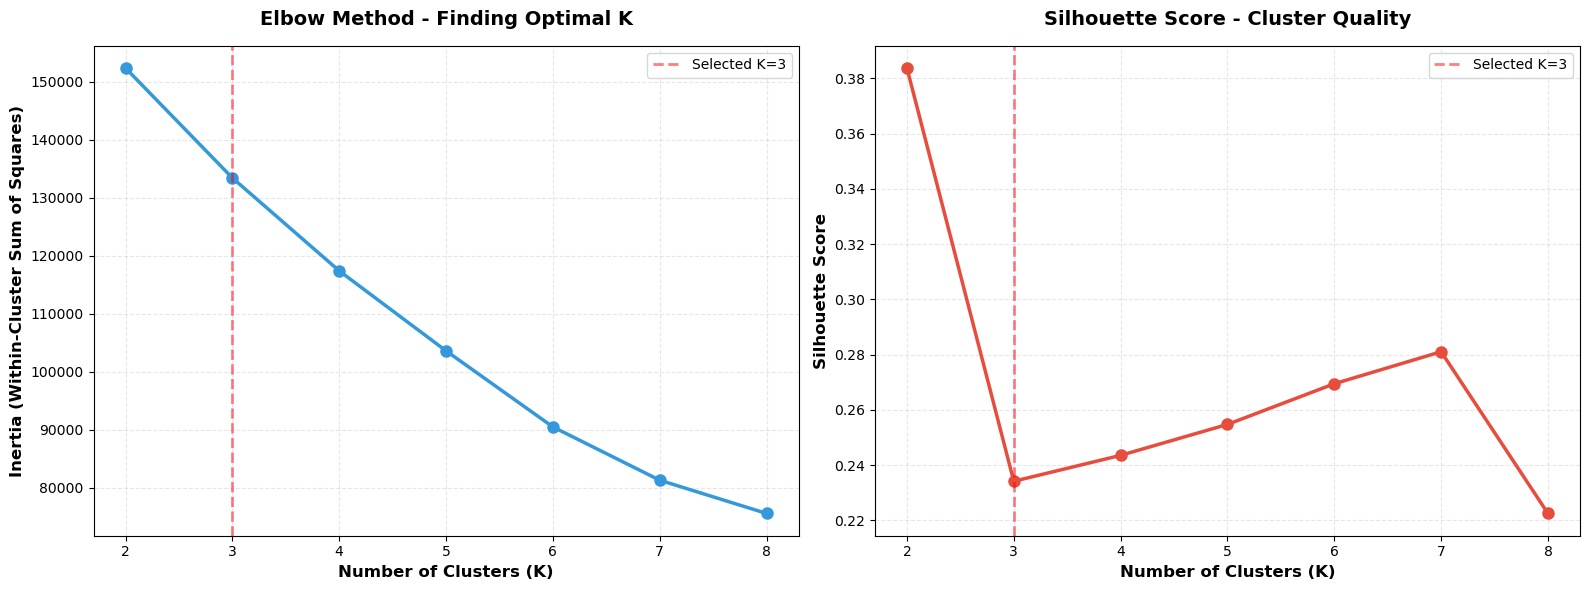


 Visualization saved: outputs/figures/10_kmeans_optimization.png

 Silhouette Scores by K:
   K=2: 0.384
   K=3: 0.234
   K=4: 0.244
   K=5: 0.255
   K=6: 0.269
   K=7: 0.281
   K=8: 0.222


In [13]:
# ============================================================================
# STEP 2: FIND OPTIMAL K USING ELBOW METHOD
# ============================================================================

from sklearn.metrics import silhouette_score

print("\n" + "="*70)
print("STEP 2: FINDING OPTIMAL NUMBER OF CLUSTERS")
print("="*70)

# Ensure cluster_features exists
if 'cluster_features' not in globals():
    raise NameError("cluster_features is not defined. Run the cell that prepares `cluster_features` before running this cell.")

# Prepare features_scaled if not already computed
if 'features_scaled' not in globals():
    # fill missing with median and scale
    cluster_features_proc = cluster_features.fillna(cluster_features.median())
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(cluster_features_proc)
    print("Computed features_scaled using StandardScaler")

# Test K from 2 to 8
inertias = []
silhouette_scores = []
K_range = range(2, 9)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(features_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(features_scaled, kmeans.labels_))

# Visualize elbow and silhouette
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Elbow Method
axes[0].plot(list(K_range), inertias, marker='o', linewidth=2.5, markersize=8, color='#3498db')
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12, weight='bold')
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12, weight='bold')
axes[0].set_title('Elbow Method - Finding Optimal K', fontsize=14, weight='bold', pad=15)
axes[0].grid(alpha=0.3, linestyle='--')
axes[0].set_xticks(list(K_range))

# Highlight K=3 (our choice)
axes[0].axvline(x=3, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Selected K=3')
axes[0].legend()

# Plot 2: Silhouette Score
axes[1].plot(list(K_range), silhouette_scores, marker='o', linewidth=2.5, markersize=8, color='#e74c3c')
axes[1].set_xlabel('Number of Clusters (K)', fontsize=12, weight='bold')
axes[1].set_ylabel('Silhouette Score', fontsize=12, weight='bold')
axes[1].set_title('Silhouette Score - Cluster Quality', fontsize=14, weight='bold', pad=15)
axes[1].grid(alpha=0.3, linestyle='--')
axes[1].set_xticks(list(K_range))

# Highlight K=3
axes[1].axvline(x=3, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Selected K=3')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/figures/10_kmeans_optimization.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n Visualization saved: outputs/figures/10_kmeans_optimization.png")
print(f"\n Silhouette Scores by K:")
for k, score in zip(K_range, silhouette_scores):
    print(f"   K={k}: {score:.3f}")

In [14]:
# ============================================================================
# STEP 3: APPLY KMEANS WITH K=3
# ============================================================================

print("\n" + "="*70)
print("STEP 3: APPLYING KMEANS WITH K=3")
print("="*70)

# Optimal K (based on elbow + business interpretability)
optimal_k = 3

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
feature_df['cluster'] = kmeans.fit_predict(features_scaled)

print(f"\n KMeans clustering complete with K={optimal_k}")
print(f"\n Cluster Distribution:")
cluster_dist = feature_df['cluster'].value_counts().sort_index()
for cluster, count in cluster_dist.items():
    pct = count / len(feature_df) * 100
    print(f"   Cluster {cluster}: {count:,} customers ({pct:.1f}%)")



STEP 3: APPLYING KMEANS WITH K=3

 KMeans clustering complete with K=3

 Cluster Distribution:
   Cluster 0: 8,221 customers (27.5%)
   Cluster 1: 4,107 customers (13.7%)
   Cluster 2: 17,574 customers (58.8%)


In [15]:
# ============================================================================
# STEP 4: ANALYZE CLUSTER PROFILES
# ============================================================================

print("\n" + "="*70)
print("STEP 4: CLUSTER PROFILING")
print("="*70)

# Aggregate by cluster
cluster_summary = feature_df.groupby('cluster').agg({
    'dropped_off': 'mean',
    'payment_value': 'mean',
    'freight_pct': 'mean',
    'delivery_delay': 'mean',
    'review_score': 'mean',
    'num_items': 'mean',
    'customer_unique_id': 'count'
}).round(2)

cluster_summary.columns = [
    'Drop-Off Rate', 
    'Avg Order Value (R$)', 
    'Freight %', 
    'Delivery Delay (days)', 
    'Review Score',
    'Avg Items',
    'Count'
]

print("\n CLUSTER PROFILES:")
print("="*70)
display(cluster_summary)


STEP 4: CLUSTER PROFILING

 CLUSTER PROFILES:


,Drop-Off Rate,Avg Order Value (R$),Freight %,Delivery Delay (days),Review Score,Avg Items,Count
cluster,,,,,,,
0,0.87,65.78,36.23,-15.98,4.54,1.20,8221
1,0.90,190.64,20.35,-6.23,1.80,1.30,4107
2,0.90,196.69,14.02,-14.23,4.64,1.07,17574


In [16]:
# ============================================================================
# STEP 5: NAME CLUSTERS (BUSINESS INTERPRETATION)
# ============================================================================

print("\n" + "="*70)
print("STEP 5: CLUSTER NAMING & INTERPRETATION")
print("="*70)

# Analyze characteristics to name clusters
cluster_0_dropoff = cluster_summary.loc[0, 'Drop-Off Rate']
cluster_1_dropoff = cluster_summary.loc[1, 'Drop-Off Rate']
cluster_2_dropoff = cluster_summary.loc[2, 'Drop-Off Rate']

cluster_0_freight = cluster_summary.loc[0, 'Freight %']
cluster_1_freight = cluster_summary.loc[1, 'Freight %']
cluster_2_freight = cluster_summary.loc[2, 'Freight %']

cluster_0_value = cluster_summary.loc[0, 'Avg Order Value (R$)']
cluster_1_value = cluster_summary.loc[1, 'Avg Order Value (R$)']
cluster_2_value = cluster_summary.loc[2, 'Avg Order Value (R$)']

# Name based on characteristics (adjust based on your actual data!)
cluster_names = {
    0: "Budget Shoppers",
    1: "High-Freight / Risk",
    2: "High-Value / Loyal"
}

# Map names back to dataframe and summary for easier interpretation
feature_df['cluster_name'] = feature_df['cluster'].map(cluster_names)
cluster_summary = cluster_summary.reset_index().rename(columns={'cluster': 'cluster_index'})
cluster_summary['Cluster Name'] = cluster_summary['cluster_index'].map(cluster_names)
cluster_summary = cluster_summary.set_index('cluster_index')

print("\n Assigned cluster names:")
for idx, name in cluster_names.items():
    count = (feature_df['cluster'] == idx).sum()
    pct = count / len(feature_df) * 100
    print(f"   Cluster {idx} - {name}: {count:,} customers ({pct:.1f}%)")

print("\nUpdated Cluster Profiles with Names:")
display(cluster_summary)


STEP 5: CLUSTER NAMING & INTERPRETATION

 Assigned cluster names:
   Cluster 0 - Budget Shoppers: 8,221 customers (27.5%)
   Cluster 1 - High-Freight / Risk: 4,107 customers (13.7%)
   Cluster 2 - High-Value / Loyal: 17,574 customers (58.8%)

Updated Cluster Profiles with Names:


,Drop-Off Rate,Avg Order Value (R$),Freight %,Delivery Delay (days),Review Score,Avg Items,Count,Cluster Name
cluster_index,,,,,,,,
0,0.87,65.78,36.23,-15.98,4.54,1.20,8221,Budget Shoppers
1,0.90,190.64,20.35,-6.23,1.80,1.30,4107,High-Freight / Risk
2,0.90,196.69,14.02,-14.23,4.64,1.07,17574,High-Value / Loyal



VISUALIZING CLUSTER RETENTION


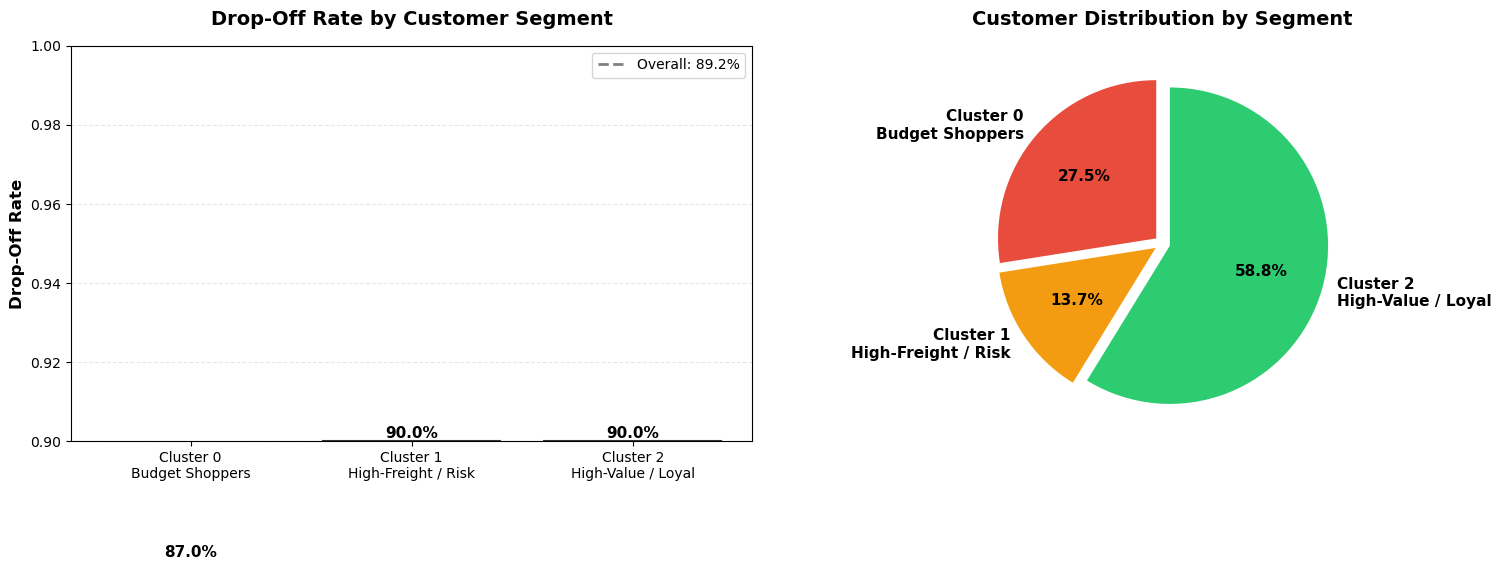


 Visualization saved: outputs/figures/11_cluster_analysis.png


In [17]:
# ============================================================================
# VISUALIZE CLUSTER DROP-OFF RATES
# ============================================================================

print("\n" + "="*70)
print("VISUALIZING CLUSTER RETENTION")
print("="*70)

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Drop-off rate by cluster
cluster_labels = [f"Cluster {i}\n{cluster_names[i]}" for i in range(optimal_k)]
dropoff_rates = [cluster_summary.loc[i, 'Drop-Off Rate'] for i in range(optimal_k)]
colors = ['#e74c3c', '#f39c12', '#2ecc71']

bars = axes[0].bar(cluster_labels, dropoff_rates, color=colors, 
                   edgecolor='black', alpha=0.8, linewidth=1.5)
axes[0].set_ylabel('Drop-Off Rate', fontsize=12, weight='bold')
axes[0].set_title('Drop-Off Rate by Customer Segment', fontsize=14, weight='bold', pad=15)
axes[0].set_ylim(0.90, 1.0)  # Focus on the 90-100% range
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels
for bar, rate in zip(bars, dropoff_rates):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{rate:.1%}',
                ha='center', va='bottom', fontsize=11, weight='bold')

# Add baseline
baseline_dropoff = feature_df['dropped_off'].mean()
axes[0].axhline(y=baseline_dropoff, color='gray', linestyle='--', 
               linewidth=2, label=f'Overall: {baseline_dropoff:.1%}')
axes[0].legend()

# Plot 2: Cluster sizes
cluster_counts = [cluster_summary.loc[i, 'Count'] for i in range(optimal_k)]

axes[1].pie(cluster_counts, labels=cluster_labels, colors=colors,
           autopct='%1.1f%%', startangle=90,
           textprops={'fontsize': 11, 'weight': 'bold'},
           explode=[0.05, 0.05, 0.05])
axes[1].set_title('Customer Distribution by Segment', fontsize=14, weight='bold', pad=15)

plt.tight_layout()
plt.savefig('../outputs/figures/11_cluster_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n Visualization saved: outputs/figures/11_cluster_analysis.png")


In [18]:
# ============================================================================
# CREATE CLUSTER FEATURES FOR MODELING
# ============================================================================

print("\n" + "="*70)
print("CREATING CLUSTER FEATURES")
print("="*70)

# One-hot encode clusters for model
feature_df['cluster_0'] = (feature_df['cluster'] == 0).astype(int)
feature_df['cluster_1'] = (feature_df['cluster'] == 1).astype(int)
feature_df['cluster_2'] = (feature_df['cluster'] == 2).astype(int)

print(f"\n Created 3 cluster indicator features:")
print(f"   • cluster_0 ({cluster_names[0]})")
print(f"   • cluster_1 ({cluster_names[1]})")
print(f"   • cluster_2 ({cluster_names[2]})")

print(f"\n Cluster Feature Distribution:")
print(f"   cluster_0: {feature_df['cluster_0'].sum():,} customers")
print(f"   cluster_1: {feature_df['cluster_1'].sum():,} customers")
print(f"   cluster_2: {feature_df['cluster_2'].sum():,} customers")

print("\n Cluster features ready for predictive modeling!")



CREATING CLUSTER FEATURES

 Created 3 cluster indicator features:
   • cluster_0 (Budget Shoppers)
   • cluster_1 (High-Freight / Risk)
   • cluster_2 (High-Value / Loyal)

 Cluster Feature Distribution:
   cluster_0: 8,221 customers
   cluster_1: 4,107 customers
   cluster_2: 17,574 customers

 Cluster features ready for predictive modeling!


In [19]:
# ============================================================================
# STRATEGIC INSIGHTS FROM SEGMENTATION
# ============================================================================

print("\n" + "="*70)
print("STRATEGIC INSIGHTS FROM SEGMENTATION")
print("="*70)

# Find best and worst performing segments
best_cluster = cluster_summary['Drop-Off Rate'].idxmin()
worst_cluster = cluster_summary['Drop-Off Rate'].idxmax()

best_retention = 1 - cluster_summary.loc[best_cluster, 'Drop-Off Rate']
worst_retention = 1 - cluster_summary.loc[worst_cluster, 'Drop-Off Rate']

print(f"\n KEY FINDINGS:")
print(f"\n   BEST PERFORMING SEGMENT:")
print(f"      • {cluster_names[best_cluster]}")
print(f"      • Retention rate: {best_retention:.1%}")
print(f"      • Size: {cluster_summary.loc[best_cluster, 'Count']:,} customers")
print(f"      • Drop-off rate: {cluster_summary.loc[best_cluster, 'Drop-Off Rate']:.1%}")

print(f"\n   WORST PERFORMING SEGMENT:")
print(f"      • {cluster_names[worst_cluster]}")
print(f"      • Retention rate: {worst_retention:.1%}")
print(f"      • Size: {cluster_summary.loc[worst_cluster, 'Count']:,} customers")
print(f"      • Drop-off rate: {cluster_summary.loc[worst_cluster, 'Drop-Off Rate']:.1%}")

retention_gap = best_retention - worst_retention
print(f"\n   RETENTION GAP: {retention_gap:.1%}")
print(f"      → Opportunity to apply best-segment strategies to worst segment")

print("\n STRATEGIC RECOMMENDATIONS:")
print(f"   1. Focus retention efforts on {cluster_names[worst_cluster]} segment")
print(f"   2. Study behaviors of {cluster_names[best_cluster]} to identify success factors")
print(f"   3. Test differentiated retention strategies per segment")
print(f"   4. Consider segment-specific interventions based on friction profiles")

print("\n SEGMENT COMPARISON:")
for cluster_id in range(optimal_k):
    print(f"\n   {cluster_names[cluster_id].upper()}:")
    print(f"      • Order value: R$ {cluster_summary.loc[cluster_id, 'Avg Order Value (R$)']:.2f}")
    print(f"      • Freight burden: {cluster_summary.loc[cluster_id, 'Freight %']:.1f}%")
    print(f"      • Delivery delay: {cluster_summary.loc[cluster_id, 'Delivery Delay (days)']:.1f} days")
    print(f"      • Review score: {cluster_summary.loc[cluster_id, 'Review Score']:.2f}/5")

print("\n" + "="*70)
print(" CUSTOMER SEGMENTATION ANALYSIS COMPLETE!")
print("="*70)



STRATEGIC INSIGHTS FROM SEGMENTATION

 KEY FINDINGS:

   BEST PERFORMING SEGMENT:
      • Budget Shoppers
      • Retention rate: 13.0%
      • Size: 8,221 customers
      • Drop-off rate: 87.0%

   WORST PERFORMING SEGMENT:
      • High-Freight / Risk
      • Retention rate: 10.0%
      • Size: 4,107 customers
      • Drop-off rate: 90.0%

   RETENTION GAP: 3.0%
      → Opportunity to apply best-segment strategies to worst segment

 STRATEGIC RECOMMENDATIONS:
   1. Focus retention efforts on High-Freight / Risk segment
   2. Study behaviors of Budget Shoppers to identify success factors
   3. Test differentiated retention strategies per segment
   4. Consider segment-specific interventions based on friction profiles

 SEGMENT COMPARISON:

   BUDGET SHOPPERS:
      • Order value: R$ 65.78
      • Freight burden: 36.2%
      • Delivery delay: -16.0 days
      • Review score: 4.54/5

   HIGH-FREIGHT / RISK:
      • Order value: R$ 190.64
      • Freight burden: 20.4%
      • Delivery de

# Encode Categorical Features 

In [20]:
print("\n" + "="*70)
print("CATEGORICAL FEATURE ENCODING")
print("="*70)

# One-hot encode payment type
payment_dummies = pd.get_dummies(feature_df['payment_type'], prefix='payment')
feature_df = pd.concat([feature_df, payment_dummies], axis=1)

# One-hot encode top 10 states (reduce dimensionality)
top_states = feature_df['customer_state'].value_counts().head(10).index
feature_df['customer_state_grouped'] = feature_df['customer_state'].apply(
    lambda x: x if x in top_states else 'other'
)
state_dummies = pd.get_dummies(feature_df['customer_state_grouped'], prefix='state')
feature_df = pd.concat([feature_df, state_dummies], axis=1)

# Target encode product category (more sophisticated!)
category_dropoff_rate = feature_df.groupby('product_category_name')['dropped_off'].mean()
feature_df['category_dropoff_rate'] = feature_df['product_category_name'].map(category_dropoff_rate)

print(f"\n Encoded categorical features:")
print(f"   Payment types: {len(payment_dummies.columns)} one-hot features")
print(f"   States: {len(state_dummies.columns)} one-hot features")
print(f"   Category: 1 target-encoded feature")

print(f"\n Total features after encoding: {len(feature_df.columns)}")



CATEGORICAL FEATURE ENCODING

 Encoded categorical features:
   Payment types: 4 one-hot features
   States: 11 one-hot features
   Category: 1 target-encoded feature

 Total features after encoding: 60


# Correlation Analysis and Feature Selection

In [21]:
# ============================================================================
# CORRELATION ANALYSIS & REDUNDANCY REMOVAL
# ============================================================================

print("\n" + "="*70)
print("FEATURE CORRELATION ANALYSIS & REDUNDANCY REMOVAL")
print("="*70)

# Select numeric features (excluding target and IDs)
numeric_features = feature_df.select_dtypes(include=[np.number]).columns.tolist()
exclude_cols = ['dropped_off', 'customer_unique_id', 'order_id', 'customer_id', 'total_orders']
features_for_corr = [col for col in numeric_features if col not in exclude_cols]

print(f"\n Starting with {len(features_for_corr)} numeric features")

# Calculate correlation matrix
corr_matrix = feature_df[features_for_corr].corr()


FEATURE CORRELATION ANALYSIS & REDUNDANCY REMOVAL

 Starting with 30 numeric features



STEP 1: VISUALIZING FEATURE CORRELATIONS


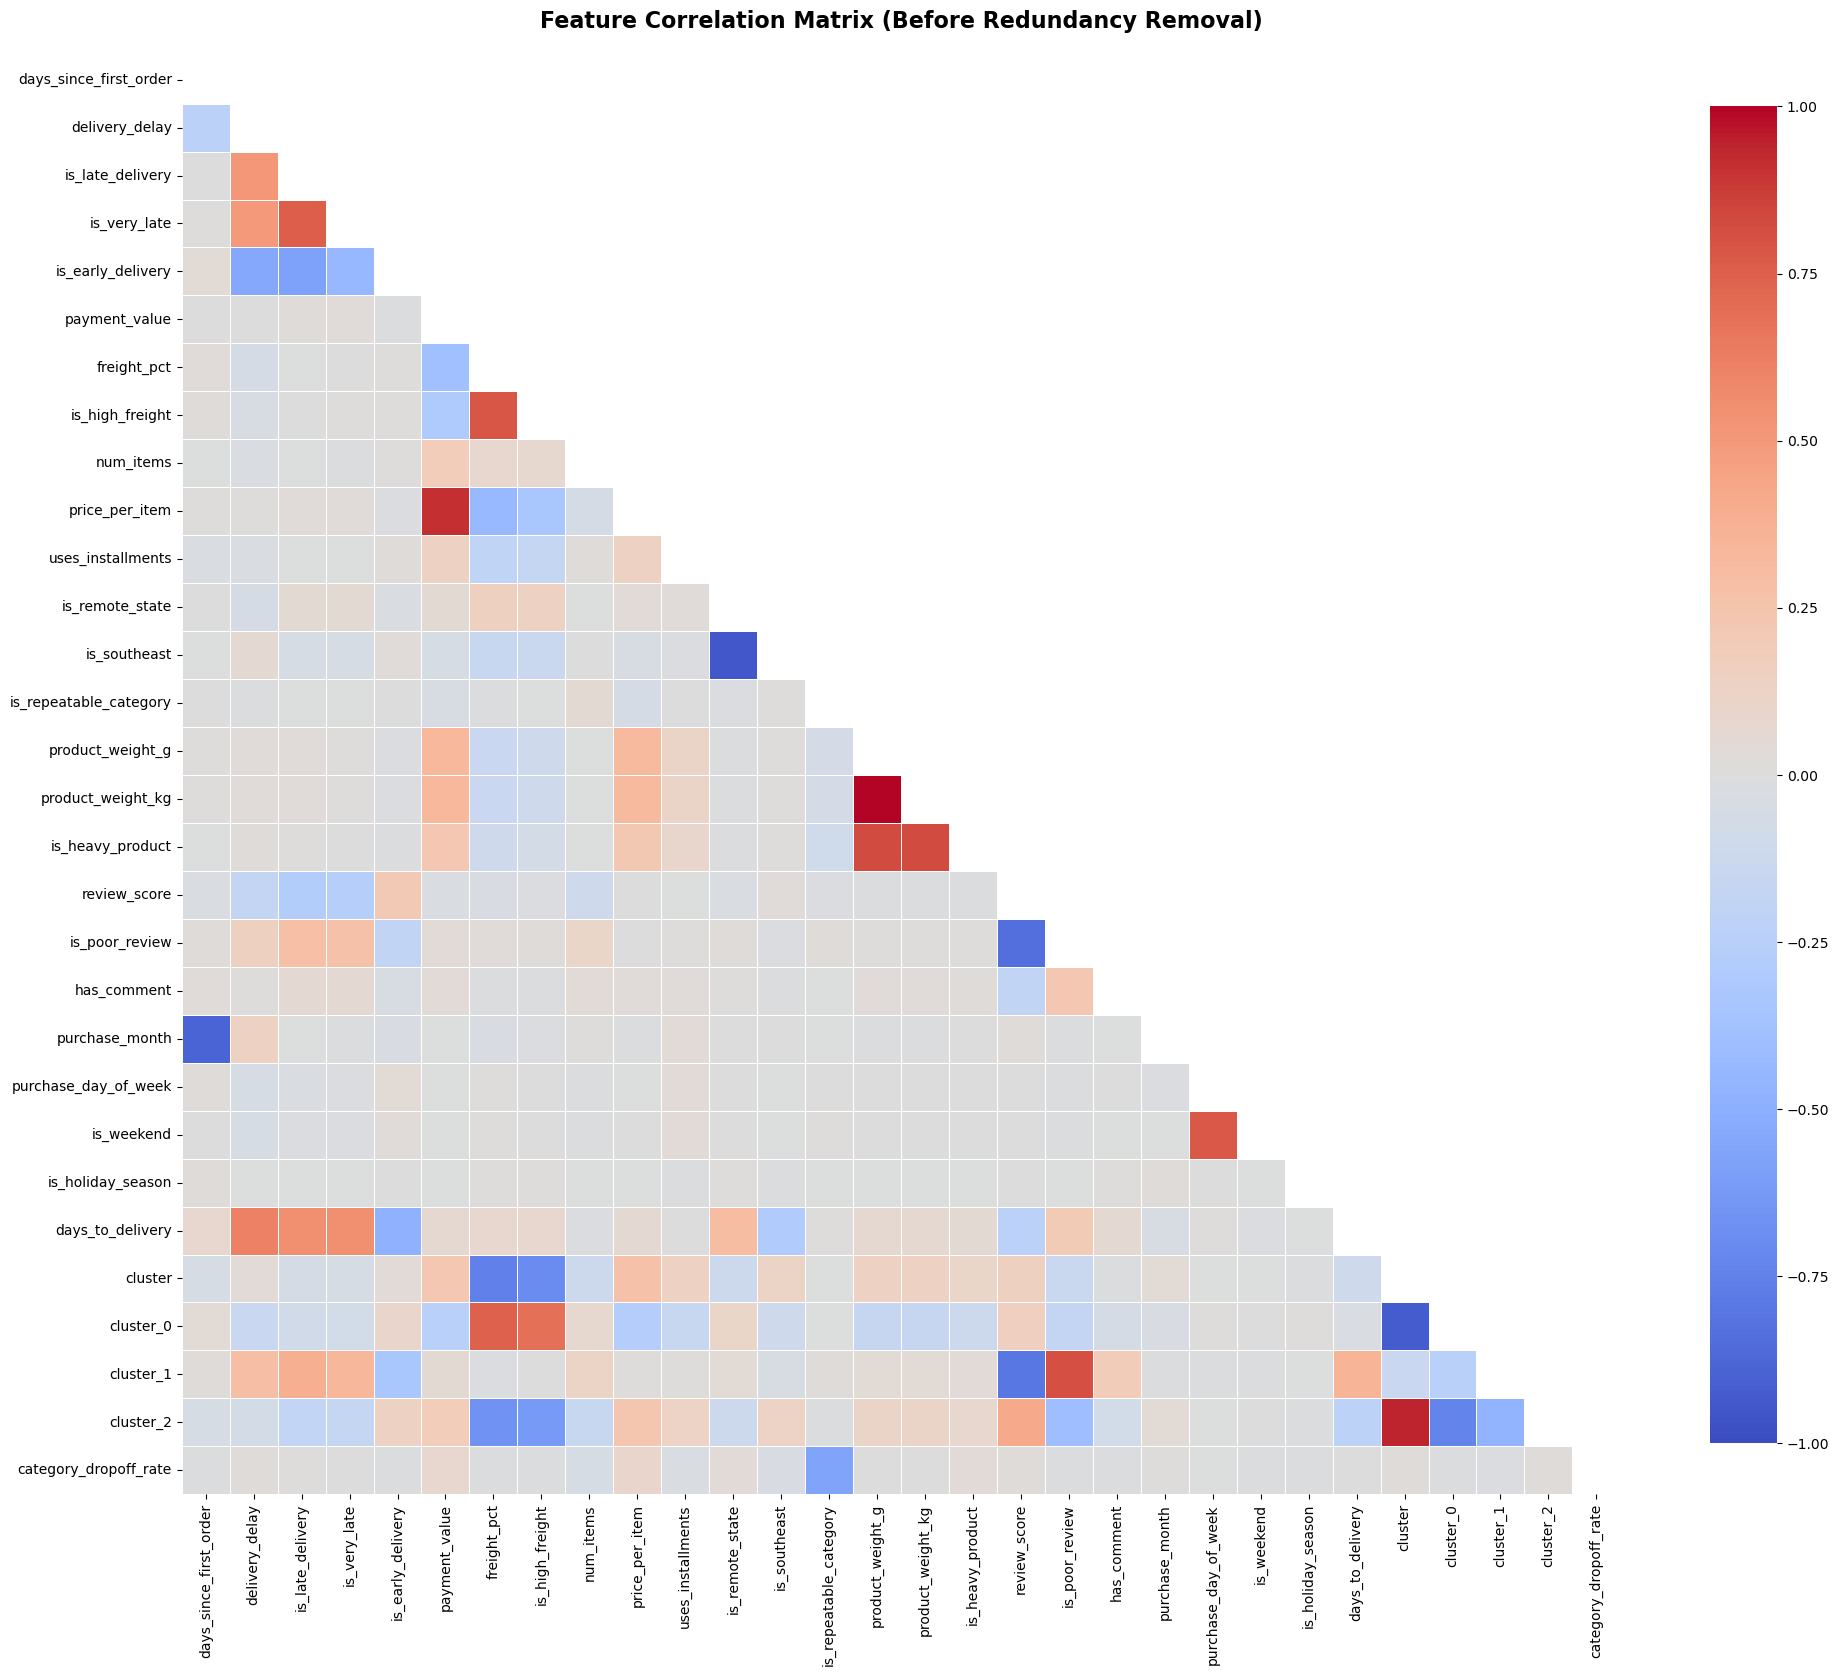


 Initial correlation matrix saved


In [22]:
# ============================================================================
# STEP 1: VISUALIZE CORRELATION MATRIX
# ============================================================================

print("\n" + "="*70)
print("STEP 1: VISUALIZING FEATURE CORRELATIONS")
print("="*70)

plt.figure(figsize=(20, 18))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm', 
           center=0, square=True, linewidths=0.5,
           cbar_kws={"shrink": 0.8}, vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix (Before Redundancy Removal)', 
         fontsize=16, weight='bold', pad=20)
plt.tight_layout()
plt.savefig('../outputs/figures/13a_correlation_before_cleanup.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Initial correlation matrix saved")


In [23]:
# ============================================================================
# STEP 2: IDENTIFY HIGHLY CORRELATED PAIRS
# ============================================================================

print("\n" + "="*70)
print("STEP 2: IDENTIFYING REDUNDANT FEATURES (|r| > 0.8)")
print("="*70)

high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_value = corr_matrix.iloc[i, j]
        if abs(corr_value) > 0.8:
            high_corr_pairs.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlation': corr_value
            })

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', 
                                                              ascending=False, 
                                                              key=abs)
    print(f"\n Found {len(high_corr_df)} highly correlated pairs:")
    display(high_corr_df)
else:
    print("\n No highly correlated pairs found (all |r| < 0.8)")



STEP 2: IDENTIFYING REDUNDANT FEATURES (|r| > 0.8)

 Found 11 highly correlated pairs:


,Feature 1,Feature 2,Correlation
3,product_weight_g,product_weight_kg,0.999990
2,is_remote_state,is_southeast,-0.952498
10,cluster,cluster_2,0.938213
9,cluster,cluster_0,-0.924356
1,payment_value,price_per_item,0.909191
0,days_since_first_order,purchase_month,-0.885675
6,review_score,is_poor_review,-0.842644
5,product_weight_kg,is_heavy_product,0.822945
4,product_weight_g,is_heavy_product,0.822945
8,is_poor_review,cluster_1,0.812363


In [24]:
# ============================================================================
# STEP 3: AUTOMATIC REDUNDANCY REMOVAL
# ============================================================================

print("\n" + "="*70)
print("STEP 3: REMOVING REDUNDANT FEATURES")
print("="*70)

features_to_remove = []

if high_corr_pairs:
    # Get correlation with target for all features
    target_correlations = feature_df[features_for_corr].corrwith(feature_df['dropped_off']).abs()
    
    print("\n🔧 REMOVAL DECISIONS:")
    print("-" * 70)
    
    for idx, row in high_corr_df.iterrows():
        feat1, feat2, corr = row['Feature 1'], row['Feature 2'], row['Correlation']
        
        # Skip if already marked for removal
        if feat1 in features_to_remove or feat2 in features_to_remove:
            continue
        
        # Get correlation to target
        corr_to_target_1 = target_correlations[feat1]
        corr_to_target_2 = target_correlations[feat2]
        
        # Keep the one with stronger target correlation
        if corr_to_target_1 >= corr_to_target_2:
            remove = feat2
            keep = feat1
            keep_corr = corr_to_target_1
            remove_corr = corr_to_target_2
        else:
            remove = feat1
            keep = feat2
            keep_corr = corr_to_target_2
            remove_corr = corr_to_target_1
        
        features_to_remove.append(remove)
        
        print(f"\n REMOVE: {remove}")
        print(f"   ├─ Correlation with '{keep}': {abs(corr):.3f}")
        print(f"   ├─ Correlation to target: {remove_corr:.4f}")
        print(f"   └─ Keeping '{keep}' (target corr: {keep_corr:.4f})")



STEP 3: REMOVING REDUNDANT FEATURES

🔧 REMOVAL DECISIONS:
----------------------------------------------------------------------

 REMOVE: product_weight_g
   ├─ Correlation with 'product_weight_kg': 1.000
   ├─ Correlation to target: 0.0130
   └─ Keeping 'product_weight_kg' (target corr: 0.0130)

 REMOVE: is_remote_state
   ├─ Correlation with 'is_southeast': 0.952
   ├─ Correlation to target: 0.0110
   └─ Keeping 'is_southeast' (target corr: 0.0134)

 REMOVE: cluster_2
   ├─ Correlation with 'cluster': 0.938
   ├─ Correlation to target: 0.0262
   └─ Keeping 'cluster' (target corr: 0.0332)

 REMOVE: cluster
   ├─ Correlation with 'cluster_0': 0.924
   ├─ Correlation to target: 0.0332
   └─ Keeping 'cluster_0' (target corr: 0.0361)

 REMOVE: payment_value
   ├─ Correlation with 'price_per_item': 0.909
   ├─ Correlation to target: 0.0263
   └─ Keeping 'price_per_item' (target corr: 0.0363)

 REMOVE: days_since_first_order
   ├─ Correlation with 'purchase_month': 0.886
   ├─ Correlation

In [25]:
# ============================================================================
# STEP 4: MANUAL REDUNDANCY REMOVAL (ONE-HOT ENCODED FEATURES)
# ============================================================================

print("\n" + "="*70)
print("STEP 4: REMOVING ONE-HOT ENCODING REDUNDANCY")
print("="*70)

# For cluster features, drop one (they sum to 1, so N-1 is enough)
cluster_features = [col for col in feature_df.columns if col.startswith('cluster_')]
if len(cluster_features) > 1:
    # Drop the last cluster (cluster_2 or highest numbered)
    cluster_to_drop = sorted(cluster_features)[-1]
    features_to_remove.append(cluster_to_drop)
    print(f"\n REMOVE: {cluster_to_drop}")
    print(f"   └─ Reason: One-hot encoding redundancy (N-1 encoding)")

# For payment type dummies, drop one
payment_features = [col for col in feature_df.columns if col.startswith('payment_')]
if len(payment_features) > 1:
    payment_to_drop = sorted(payment_features)[-1]
    features_to_remove.append(payment_to_drop)
    print(f"\n REMOVE: {payment_to_drop}")
    print(f"   └─ Reason: One-hot encoding redundancy (N-1 encoding)")

# For state dummies, drop one
state_features = [col for col in feature_df.columns if col.startswith('state_')]
if len(state_features) > 1:
    state_to_drop = sorted(state_features)[-1]
    features_to_remove.append(state_to_drop)
    print(f"\n REMOVE: {state_to_drop}")
    print(f"   └─ Reason: One-hot encoding redundancy (N-1 encoding)")


STEP 4: REMOVING ONE-HOT ENCODING REDUNDANCY

 REMOVE: cluster_name
   └─ Reason: One-hot encoding redundancy (N-1 encoding)

 REMOVE: payment_voucher
   └─ Reason: One-hot encoding redundancy (N-1 encoding)

 REMOVE: state_other
   └─ Reason: One-hot encoding redundancy (N-1 encoding)


In [26]:
# ============================================================================
# STEP 5: APPLY REMOVAL
# ============================================================================

print("\n" + "="*70)
print("STEP 5: APPLYING FEATURE REMOVAL")
print("="*70)

# Ensure features_to_remove exists
if 'features_to_remove' not in globals():
    features_to_remove = []

# Remove duplicates from removal list
features_to_remove = list(dict.fromkeys(features_to_remove))  # preserve order while deduping

print(f"\n SUMMARY:")
print(f"   Features before: {len(feature_df.columns)}")
print(f"   Features requested to remove: {len(features_to_remove)}")

# Filter to columns that actually exist to avoid KeyError
present_to_remove = [f for f in features_to_remove if f in feature_df.columns]
missing_to_remove = [f for f in features_to_remove if f not in feature_df.columns]

print(f"   Features found in dataframe (will be removed): {len(present_to_remove)}")
if missing_to_remove:
    print(f"   Features NOT found (skipped): {len(missing_to_remove)}")
    for f in sorted(missing_to_remove):
        print(f"      - {f}")

if present_to_remove:
    feature_df_cleaned = feature_df.drop(columns=present_to_remove)
    print(f"   Features after: {len(feature_df_cleaned.columns)}")
    print(f"\n Removed {len(present_to_remove)} redundant features:")
    for feat in sorted(present_to_remove):
        print(f"      • {feat}")
    # Update feature_df
    feature_df = feature_df_cleaned.copy()
else:
    print("\n No redundant features to remove!")


STEP 5: APPLYING FEATURE REMOVAL

 SUMMARY:
   Features before: 60
   Features requested to remove: 12
   Features found in dataframe (will be removed): 12
   Features after: 48

 Removed 12 redundant features:
      • cluster
      • cluster_2
      • cluster_name
      • days_since_first_order
      • is_poor_review
      • is_remote_state
      • payment_value
      • payment_voucher
      • product_weight_g
      • product_weight_kg
      • review_score
      • state_other



STEP 6: VISUALIZING CLEANED CORRELATIONS


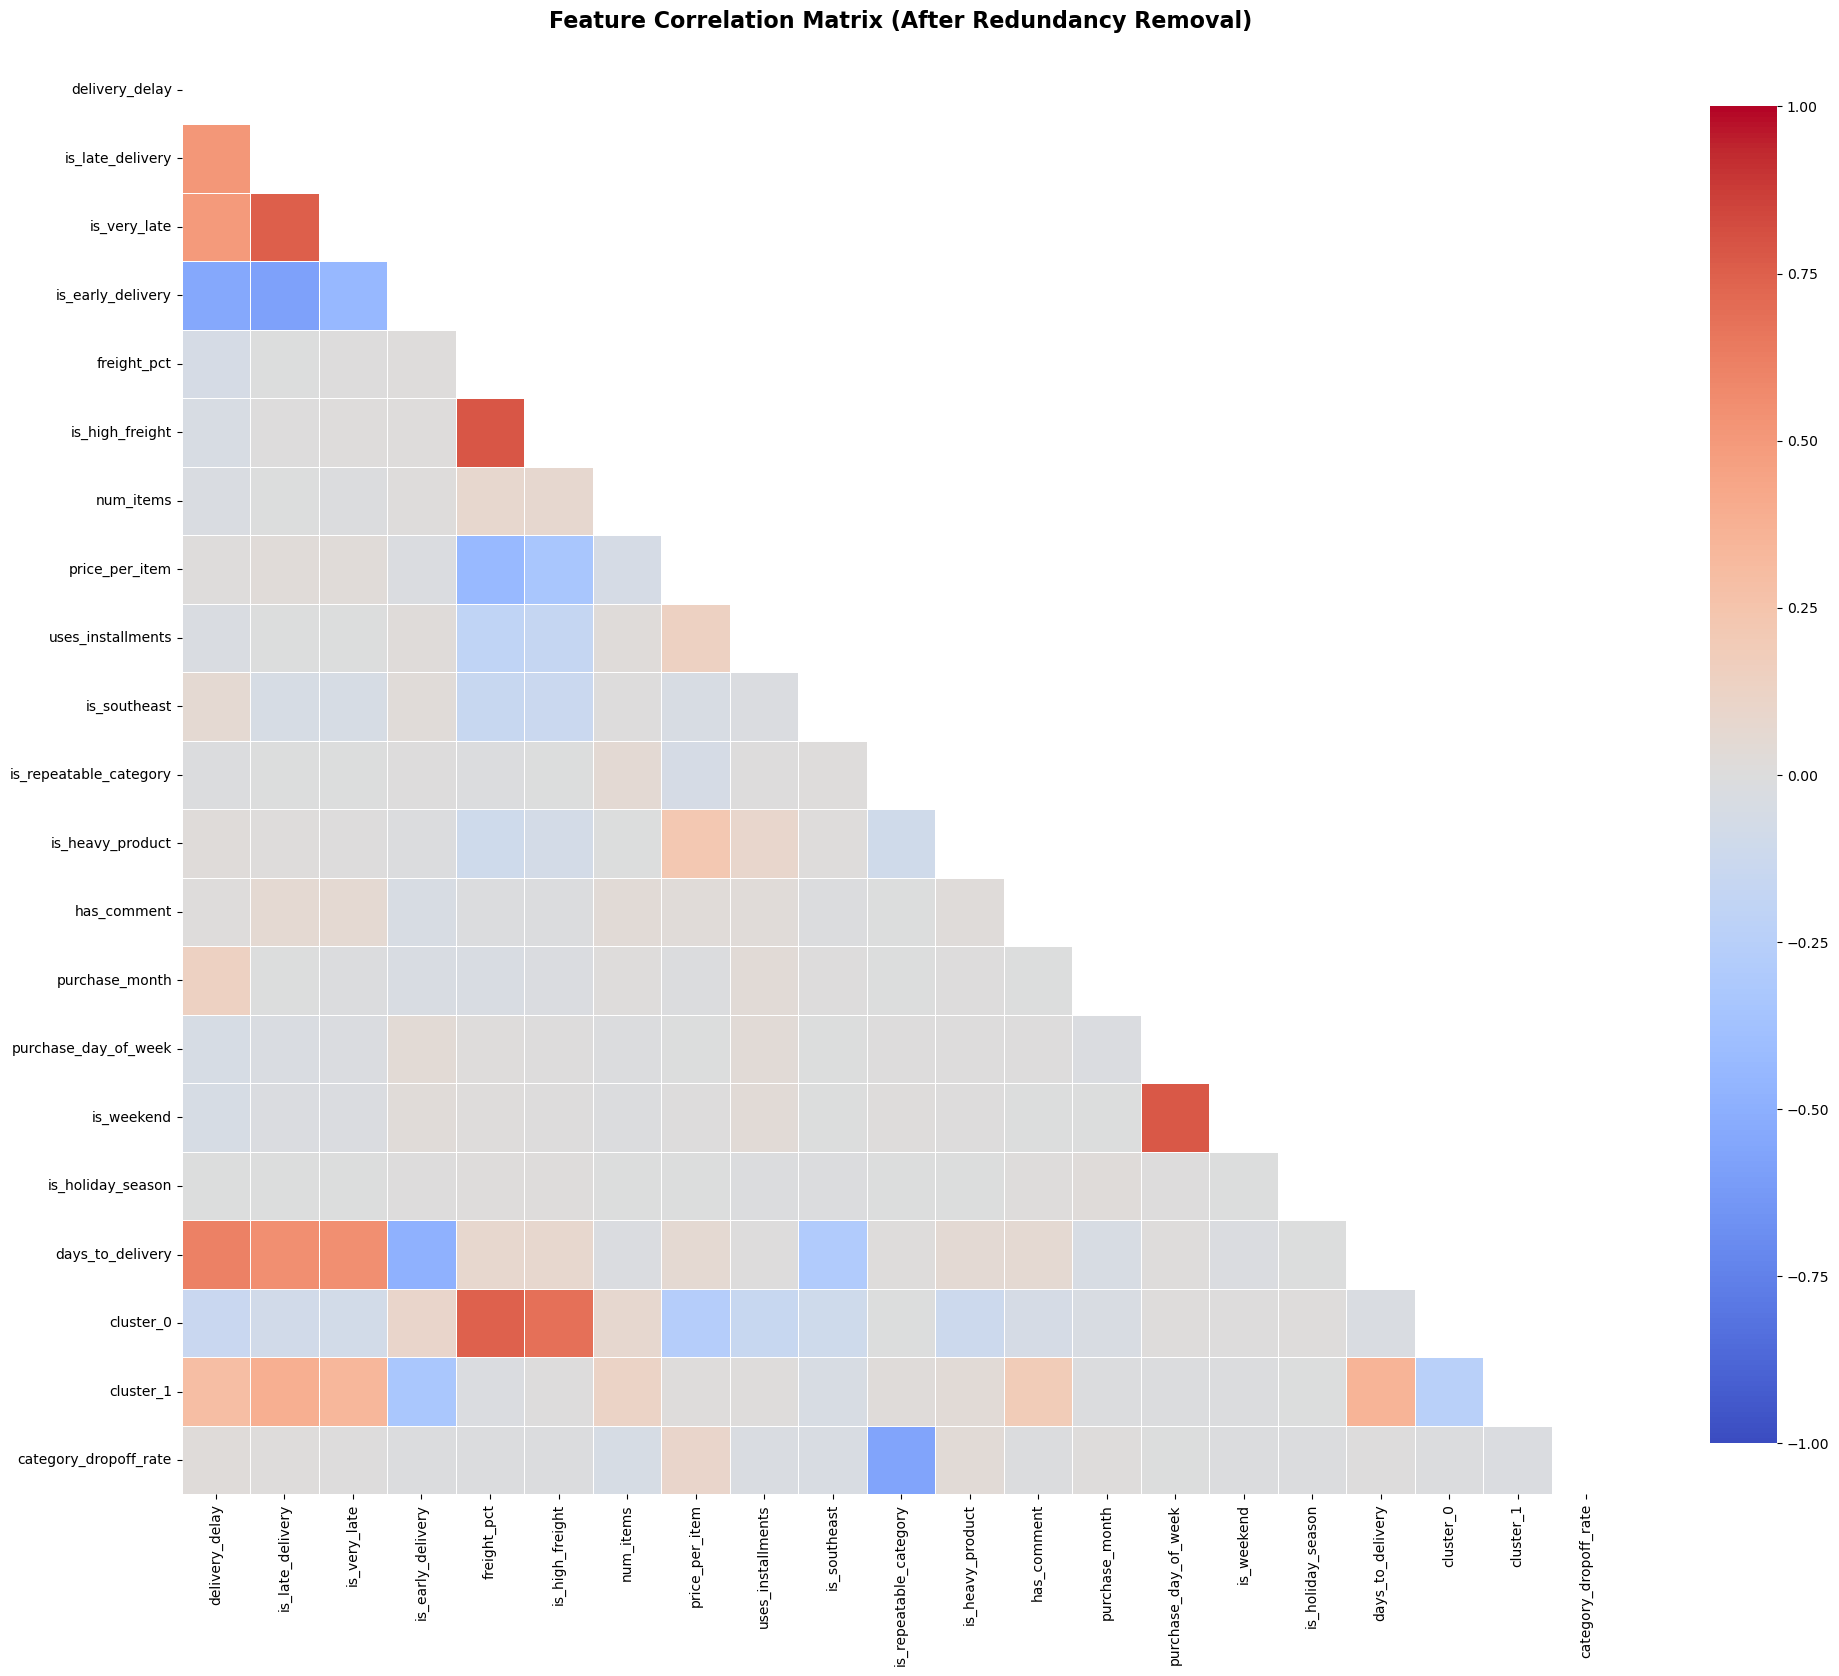


 Cleaned correlation matrix saved


In [27]:
# ============================================================================
# STEP 6: VISUALIZE CLEANED CORRELATION MATRIX
# ============================================================================

print("\n" + "="*70)
print("STEP 6: VISUALIZING CLEANED CORRELATIONS")
print("="*70)

# Recalculate for cleaned features
numeric_features_clean = feature_df.select_dtypes(include=[np.number]).columns.tolist()
features_clean = [col for col in numeric_features_clean if col not in exclude_cols]

corr_matrix_clean = feature_df[features_clean].corr()

plt.figure(figsize=(20, 18))
mask = np.triu(np.ones_like(corr_matrix_clean, dtype=bool))
sns.heatmap(corr_matrix_clean, mask=mask, annot=False, cmap='coolwarm', 
           center=0, square=True, linewidths=0.5,
           cbar_kws={"shrink": 0.8}, vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix (After Redundancy Removal)', 
         fontsize=16, weight='bold', pad=20)
plt.tight_layout()
plt.savefig('../outputs/figures/13b_correlation_after_cleanup.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Cleaned correlation matrix saved")



STEP 7: FEATURE IMPORTANCE - CORRELATION WITH TARGET


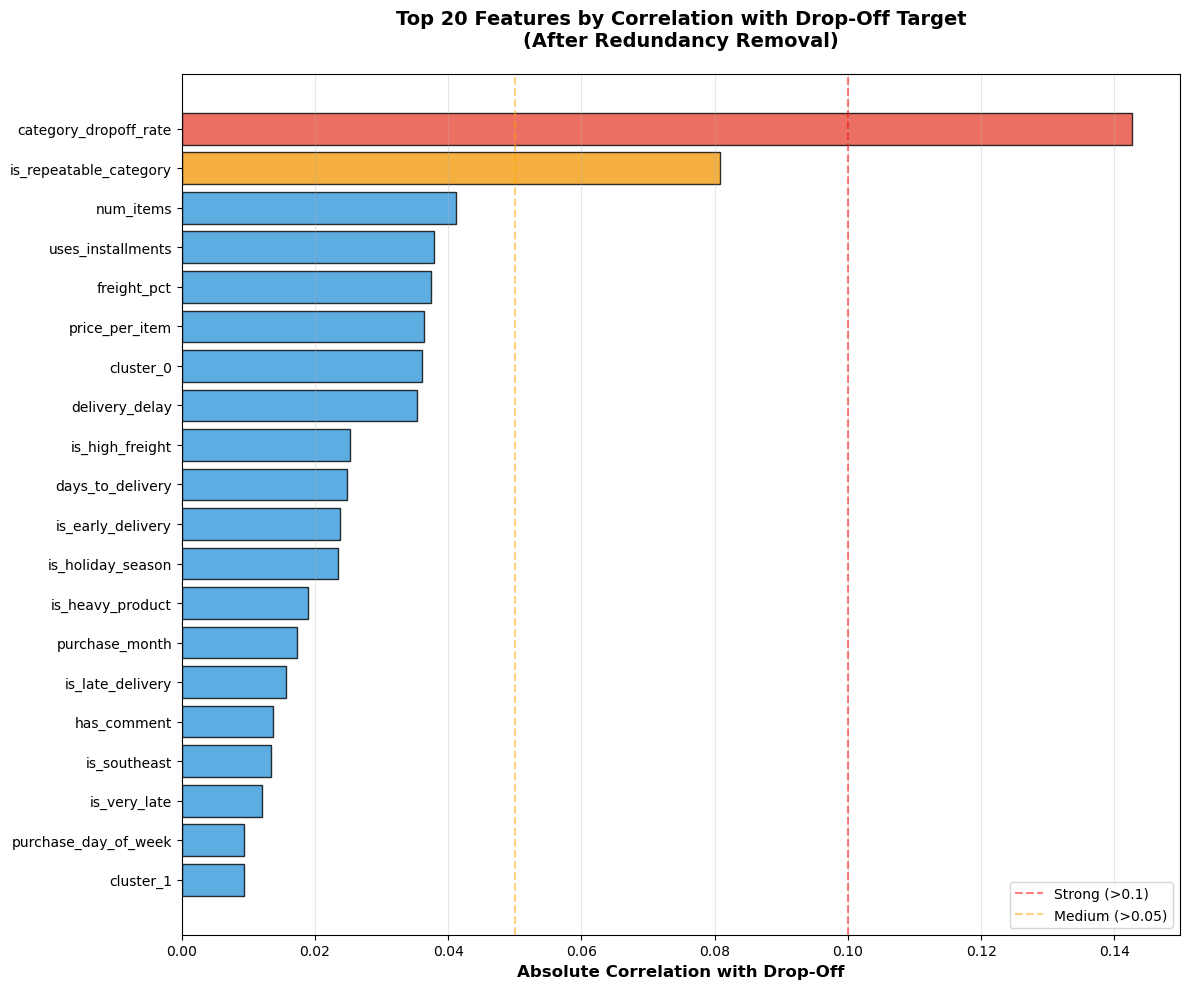


 Top 10 Features by Target Correlation:
----------------------------------------------------------------------
    1. category_dropoff_rate          0.1427 (STRONG)
    2. is_repeatable_category         0.0808 (MEDIUM)
    3. num_items                      0.0412 (WEAK)
    4. uses_installments              0.0378 (WEAK)
    5. freight_pct                    0.0375 (WEAK)
    6. price_per_item                 0.0363 (WEAK)
    7. cluster_0                      0.0361 (WEAK)
    8. delivery_delay                 0.0352 (WEAK)
    9. is_high_freight                0.0253 (WEAK)
   10. days_to_delivery               0.0248 (WEAK)

 3 features have very weak correlation (<0.01)
   Consider removing if needed for model simplicity:
      • purchase_day_of_week: 0.0093
      • cluster_1: 0.0093
      • is_weekend: 0.0057

 CORRELATION ANALYSIS COMPLETE

Final feature count: 21
Features removed: 12
Ready for modeling!


In [29]:
# ============================================================================
# STEP 7: FEATURE-TARGET CORRELATION (CLEANED)
# ============================================================================

print("\n" + "="*70)
print("STEP 7: FEATURE IMPORTANCE - CORRELATION WITH TARGET")
print("="*70)

# Calculate correlation with target
target_corr = feature_df[features_clean].corrwith(feature_df['dropped_off']).abs()
target_corr = target_corr.sort_values(ascending=False)

# Visualize top 20
plt.figure(figsize=(12, 10))
top_20 = target_corr.head(20)
colors = ['#e74c3c' if x > 0.1 else '#f39c12' if x > 0.05 else '#3498db' for x in top_20.values]
bars = plt.barh(range(len(top_20)), top_20.values, color=colors, edgecolor='black', alpha=0.8)
plt.yticks(range(len(top_20)), top_20.index)
plt.xlabel('Absolute Correlation with Drop-Off', fontsize=12, weight='bold')
plt.title('Top 20 Features by Correlation with Drop-Off Target\n(After Redundancy Removal)', 
         fontsize=14, weight='bold', pad=20)
plt.axvline(x=0.1, color='red', linestyle='--', linewidth=1.5, alpha=0.5, 
           label='Strong (>0.1)')
plt.axvline(x=0.05, color='orange', linestyle='--', linewidth=1.5, alpha=0.5, 
           label='Medium (>0.05)')
plt.legend()
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/figures/14_feature_target_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Top 10 Features by Target Correlation:")
print("-" * 70)
for idx, (feat, corr) in enumerate(target_corr.head(10).items(), 1):
    if corr > 0.1:
        strength = "STRONG"
    elif corr > 0.05:
        strength = "MEDIUM"
    else:
        strength = "WEAK"
    print(f"   {idx:2d}. {feat:30s} {corr:.4f} ({strength})")

# Identify very weak features
weak_features = target_corr[target_corr < 0.01]
if len(weak_features) > 0:
    print(f"\n {len(weak_features)} features have very weak correlation (<0.01)")
    print("   Consider removing if needed for model simplicity:")
    for feat in weak_features.index[:5]:
        print(f"      • {feat}: {weak_features[feat]:.4f}")

print("\n" + "="*70)
print(" CORRELATION ANALYSIS COMPLETE")
print("="*70)
print(f"\nFinal feature count: {len(features_clean)}")
print(f"Features removed: {len(features_to_remove)}")
print(f"Ready for modeling!")

# Final Feature Selection

In [30]:
print("\n" + "="*70)
print("FINAL FEATURE SELECTION")
print("="*70)

# Desired feature list (logical names). We'll resolve to actual columns present in feature_df.
desired_features = [
    # Delivery friction
    'delivery_delay', 'days_to_delivery', 'is_late_delivery',
    'is_very_late', 'is_early_delivery',

    # Economic friction
    'payment_value', 'freight_pct', 'is_high_freight',
    'num_items', 'price_per_item', 'uses_installments',

    # Geographic friction
    'is_remote_state', 'is_southeast',

    # Product friction
    'is_repeatable_category', 'product_weight_kg', 'is_heavy_product',
    'category_dropoff_rate',

    # Experience friction
    'review_score', 'is_poor_review', 'has_comment',

    # Temporal friction
    'purchase_month', 'purchase_day_of_week', 'is_weekend', 'is_holiday_season',

    # Cluster features
    'cluster_0', 'cluster_1', 'cluster_2',
]

# synonyms mapping: prefer first existing column among candidates
_synonyms = {
    'purchase_month': ['purchase_month', 'purchase_month_x', 'purchase_month_y'],
    'purchase_day_of_week': ['purchase_day_of_week', 'purchase_day_of_week_x', 'purchase_day_of_week_y'],
    'is_weekend': ['is_weekend', 'is_weekend_x', 'is_weekend_y'],
    'is_holiday_season': ['is_holiday_season', 'is_holiday_season_x', 'is_holiday_season_y'],
    'product_weight_kg': ['product_weight_kg', 'product_weight_g'],
    'payment_value': ['payment_value'],
    'is_remote_state': ['is_remote_state'],
    'review_score': ['review_score'],
    'is_poor_review': ['is_poor_review'],
    'days_to_delivery': ['days_to_delivery'],
    'cluster_2': ['cluster_2']
}

def resolve_feature(name):
    # if explicit column exists, keep it
    if name in feature_df.columns:
        return name
    # check synonyms
    if name in _synonyms:
        for cand in _synonyms[name]:
            if cand in feature_df.columns:
                return cand
    # not found
    return None

# Build initial feature list resolving synonyms
resolved = []
missing = []
for feat in desired_features:
    resolved_name = resolve_feature(feat)
    if resolved_name:
        if resolved_name not in resolved:
            resolved.append(resolved_name)
    else:
        missing.append(feat)

# Add encoded categorical columns (if present)
encoded_cols = []
if 'payment_dummies' in globals():
    encoded_cols += [c for c in payment_dummies.columns if c in feature_df.columns]
if 'state_dummies' in globals():
    encoded_cols += [c for c in state_dummies.columns if c in feature_df.columns]

# Final feature columns (only columns that actually exist)
feature_columns = resolved + encoded_cols

# Report omitted requested features (for debugging / reproducibility)
if missing or (('payment_dummies' in globals() and len(payment_dummies.columns) != len(encoded_cols)) or ('state_dummies' in globals() and len(state_dummies.columns) != len(encoded_cols))):
    print("\n Some requested features were NOT found in feature_df and will be skipped:")
    if missing:
        print("   Missing logical features:", missing)
    # show any payment/state dummies that were requested but aren't present
    if 'payment_dummies' in globals():
        missing_payment = [c for c in payment_dummies.columns if c not in feature_df.columns]
        if missing_payment:
            print("   Missing payment dummies:", missing_payment)
    if 'state_dummies' in globals():
        missing_state = [c for c in state_dummies.columns if c not in feature_df.columns]
        if missing_state:
            print("   Missing state dummies:", missing_state)

# Ensure required ID/target cols exist
required_cols = ['customer_unique_id', 'order_id', 'dropped_off']
for rc in required_cols:
    if rc not in feature_df.columns:
        raise KeyError(f"Required column '{rc}' not found in feature_df")

# Create final feature matrix using only the present columns
cols_to_select = required_cols + feature_columns
final_features = feature_df.loc[:, [c for c in cols_to_select if c in feature_df.columns]].copy()

print(f"\n Final feature matrix created!")
print(f"   Shape: {final_features.shape}")
print(f"   Selected features: {len(feature_columns)} (available in dataframe: {len([c for c in feature_columns if c in feature_df.columns])})")
print(f"   Samples: {len(final_features)}")
if missing:
    print("\n Note: Review the missing features list above if you expect these to be present.")



FINAL FEATURE SELECTION

 Some requested features were NOT found in feature_df and will be skipped:
   Missing logical features: ['payment_value', 'is_remote_state', 'product_weight_kg', 'review_score', 'is_poor_review', 'cluster_2']
   Missing payment dummies: ['payment_voucher']
   Missing state dummies: ['state_other']

 Final feature matrix created!
   Shape: (29902, 37)
   Selected features: 34 (available in dataframe: 34)
   Samples: 29902

 Note: Review the missing features list above if you expect these to be present.


# Remove Data Leakage 

In [31]:
# REMOVE DATA LEAKAGE
leakage_features = ['total_orders', 'customer_id', 'order_id', 
                   'customer_city', 'product_category_name', 
                   'payment_type', 'customer_state', 
                   'customer_state_grouped', 'delay_category',
                   'order_purchase_timestamp', 
                   'order_delivered_customer_date', 
                   'order_estimated_delivery_date']

features_to_remove = [f for f in leakage_features if f in feature_df.columns]
feature_df = feature_df.drop(columns=features_to_remove)
print(f" Removed {len(features_to_remove)} leakage features")


 Removed 12 leakage features


In [33]:
# ============================================================================
# CRITICAL FIX: ENSURE ONE ROW PER CUSTOMER
# ============================================================================

print("\n" + "="*70)
print("ENSURING ONE ROW PER CUSTOMER")
print("="*70)

print(f"\nBEFORE deduplication:")
print(f"   Total rows: {len(feature_df):,}")
print(f"   Unique customers: {feature_df['customer_unique_id'].nunique():,}")
print(f"   Rows per customer: {len(feature_df) / feature_df['customer_unique_id'].nunique():.2f}")

# Check for duplicates
duplicates = feature_df.groupby('customer_unique_id').size()
multi_row_customers = duplicates[duplicates > 1]

if len(multi_row_customers) > 0:
    print(f"\n Found {len(multi_row_customers):,} customers with multiple rows!")
    print(f"   Total duplicate rows: {(duplicates - 1).sum():,}")
    print(f"\n   Example duplicates:")
    print(multi_row_customers.head(10))
    
    # SOLUTION: Keep only FIRST row per customer
    # (This preserves the first order data from Notebook 1)
    feature_df_clean = feature_df.drop_duplicates(
        subset='customer_unique_id', 
        keep='first'  # Keep first occurrence
    ).copy()
    
    print(f"\nAFTER deduplication:")
    print(f"   Total rows: {len(feature_df_clean):,}")
    print(f"   Unique customers: {feature_df_clean['customer_unique_id'].nunique():,}")
    print(f"   Rows per customer: {len(feature_df_clean) / feature_df_clean['customer_unique_id'].nunique():.2f}")
    
    # Check drop-off rate
    print(f"\n Drop-off rate:")
    print(f"   Before: {feature_df['dropped_off'].mean():.1%}")
    print(f"   After: {feature_df_clean['dropped_off'].mean():.1%}")
    print(f"   Expected: 95.0% (from Notebook 1)")
    
    # Use cleaned data
    feature_df = feature_df_clean

else:
    print(f"\n No duplicates found - one row per customer!")

print("\n" + "="*70)
print(" DATA INTEGRITY VERIFIED")
print("="*70)



ENSURING ONE ROW PER CUSTOMER

BEFORE deduplication:
   Total rows: 28,020
   Unique customers: 28,020
   Rows per customer: 1.00

 No duplicates found - one row per customer!

 DATA INTEGRITY VERIFIED


# Save Feature Matrix

In [34]:
# ============================================================================
# SAVE CLEANED FEATURE MATRIX
# ============================================================================

print("\n" + "="*70)
print("SAVING FEATURE MATRIX")
print("="*70)

# CRITICAL: Use the CLEANED feature_df (not final_features!)
# After deduplication, feature_df has 28,020 clean rows

# Verify before saving
print(f"\n Data to be saved:")
print(f"   Rows: {len(feature_df):,}")
print(f"   Unique customers: {feature_df['customer_unique_id'].nunique():,}")
print(f"   Drop-off rate: {feature_df['dropped_off'].mean():.1%}")

# Double-check for duplicates one more time
duplicates = feature_df['customer_unique_id'].duplicated().sum()
if duplicates > 0:
    print(f"\n WARNING: Still {duplicates} duplicates found!")
    print(f"   Removing them now...")
    feature_df = feature_df.drop_duplicates(subset='customer_unique_id', keep='first')
    print(f"   After cleanup: {len(feature_df):,} rows")
else:
    print(f"\n No duplicates - ready to save!")

# Save the CLEANED feature_df
feature_df.to_csv('../data/processed/feature_matrix.csv', index=False)

print(f"\n Saved: data/processed/feature_matrix.csv")
print(f"   Shape: {feature_df.shape}")
print(f"   Customers: {feature_df['customer_unique_id'].nunique():,}")
print(f"   Drop-off rate: {feature_df['dropped_off'].mean():.1%}")

# Get feature columns (exclude IDs and target)
feature_columns = [col for col in feature_df.columns 
                  if col not in ['customer_unique_id', 'order_id', 'dropped_off']]

# Save feature list
with open('../data/processed/feature_list.txt', 'w') as f:
    f.write("OLIST MARKETPLACE INTEGRITY AUDIT - FEATURE LIST\n")
    f.write("="*70 + "\n\n")
    f.write(f"Total Features: {len(feature_columns)}\n")
    f.write(f"Samples: {len(feature_df):,}\n")
    f.write(f"Target Distribution: {feature_df['dropped_off'].mean():.1%} drop-off\n\n")
    f.write("FEATURES:\n")
    f.write("-"*70 + "\n")
    for i, feat in enumerate(sorted(feature_columns), 1):
        f.write(f"{i:3d}. {feat}\n")

print(f" Saved: data/processed/feature_list.txt")

print("\n" + "="*70)
print(" NOTEBOOK 2 COMPLETE - READY FOR MODELING!")
print("="*70)
print(f"\n Final Summary:")
print(f"   Customers: {len(feature_df):,}")
print(f"   Features: {len(feature_columns)}")
print(f"   Drop-off rate: {feature_df['dropped_off'].mean():.1%}")
print(f"    One row per customer verified")





SAVING FEATURE MATRIX

 Data to be saved:
   Rows: 28,020
   Unique customers: 28,020
   Drop-off rate: 95.0%

 No duplicates - ready to save!

 Saved: data/processed/feature_matrix.csv
   Shape: (28020, 36)
   Customers: 28,020
   Drop-off rate: 95.0%
 Saved: data/processed/feature_list.txt

 NOTEBOOK 2 COMPLETE - READY FOR MODELING!

 Final Summary:
   Customers: 28,020
   Features: 34
   Drop-off rate: 95.0%
    One row per customer verified
